In [2]:
import pandas as pd 
import geopandas as gpd
import os
import alphashape
import numpy as np
import warnings
warnings.filterwarnings("ignore")


ModuleNotFoundError: No module named 'dateutil.easter'

In [ ]:
# caricamento aree dove sono concessi gli spostamenti
path = ".." + os.sep + "data" + os.sep + "static" + os.sep 
area = gpd.read_file( path + "ambito_esercizio_monopattini.shp")
alpha_shape_df = None
if os.path.exists(path + "alpha_shape_area.shp"):
    alpha_shape_df = gpd.read_file(path + "alpha_shape_area.shp")
else:
    points = []
    for idx, row in area.iterrows():
        points= points + (list(area.geometry[idx].exterior.coords))
    points = np.array(points)
    alpha_shape = alphashape.alphashape(points)
    alpha_shape_df = gpd.GeoDataFrame(
        index=[0], crs=area.crs, geometry=[alpha_shape])
    alpha_shape_df.to_file(path + "alpha_shape_area.shp")


: 

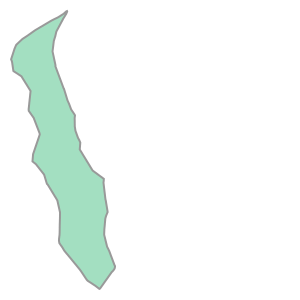

: 

In [ ]:
alpha_shape_df.geometry[0]

In [ ]:
points = []
for idx, row in alpha_shape_df.iterrows():
    points = points + (list(alpha_shape_df.geometry[idx].exterior.coords))
points = np.array(points)
alpha_shape = alphashape.alphashape(points)


: 

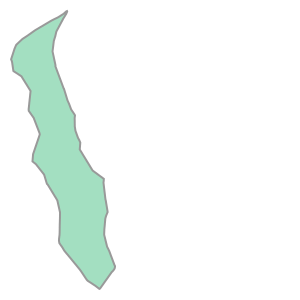

: 

In [ ]:
alphashape.alphashape(points)


In [ ]:
alpha_shape_df = gpd.GeoDataFrame(
    index=[0], crs=area.crs, geometry=[alpha_shape])


: 

In [ ]:
alpha_shape_df = alpha_shape_df.buffer(100)

: 

In [ ]:
alpha_shape_df.to_file(path + "area_valida_spostamento_monopattini_100m.shp")


: 

In [ ]:
data = pd.read_parquet(".." + os.sep + "data" +
                       os.sep + "trips_pointv3.parquet")


: 

In [ ]:
new_columns = {}
for n in list(data.columns):
    new_columns[n] = n.replace('point_','')

: 

In [ ]:
data.rename(columns=new_columns,inplace=True)

: 

In [ ]:
geo_data = gpd.GeoDataFrame(
    data,
    crs=4326,
    geometry=gpd.points_from_xy(data.longitude, data.latitude))


: 

In [ ]:
geo_data_in_area = geo_data[geo_data.to_crs(alpha_shape_df.crs).within(alpha_shape_df.geometry[0])]


: 

In [ ]:
geo_data_in_area.to_parquet(".." + os.sep + "data" + os.sep + "clean_data.parquet")

: 